# CO2 Emissions Prediction

## Objective

The objective of this project is to predict CO₂ emissions of vehicles using various vehicle specifications such as:

- Engine Size
- Cylinders
- Fuel Consumption
- Fuel Type
- Transmission

Different regression models will be compared to determine the best-performing model.

## Importing requried libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## Reading Dataset

In [2]:
dataset=pd.read_csv(f'co2.csv')
dataset.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Dataset Description

The dataset contains information about various vehicles, including their manufacturer, model, engine specifications, fuel consumption, and carbon dioxide (CO₂) emissions. These features are used to analyze the factors affecting vehicle emissions and to build predictive machine learning models.

#### Column Description

**1. Make**

* Represents the manufacturer or brand of the vehicle (e.g., Toyota, Honda, BMW, Ford).

**2. Model**

* Represents the specific model of the vehicle produced by the manufacturer.

**3. Vehicle Class**

* Indicates the category of the vehicle based on its size and purpose, such as Compact, SUV, Pickup Truck, or Minivan.

**4. Engine Size (L)**

* Represents the engine displacement measured in liters. Larger engines generally consume more fuel and produce higher CO₂ emissions.

**5. Cylinders**

* Indicates the number of cylinders present in the vehicle's engine. Vehicles with more cylinders usually generate more power but also consume more fuel.

**6. Transmission**

* Describes the transmission type of the vehicle, such as Manual or Automatic, along with the number of gears.

**7. Fuel Type**

* Specifies the type of fuel used by the vehicle, such as gasoline, diesel, ethanol, or natural gas.

**8. Fuel Consumption City (L/100 km)**

* Represents the amount of fuel consumed while driving in city conditions, measured in liters per 100 kilometers.

**9. Fuel Consumption Hwy (L/100 km)**

* Represents the amount of fuel consumed while driving on highways, measured in liters per 100 kilometers.

**10. Fuel Consumption Comb (L/100 km)**

* Represents the combined fuel consumption under both city and highway driving conditions.

**11. Fuel Consumption Comb (mpg)**

* Represents the combined fuel efficiency in miles per gallon (mpg). Higher values indicate better fuel efficiency.

**12. CO₂ Emissions (g/km)**

* Represents the amount of carbon dioxide emitted by the vehicle per kilometer traveled. This is the **target variable** used for predicting vehicle emissions.


In [3]:
# Renaming Columns for the short and ease

dataset.rename(columns={'Fuel Consumption City (L/100 km)':'Fuel_City',
                        'Fuel Consumption Hwy (L/100 km)':'Fuel_Highway',
                        'Fuel Consumption Comb (L/100 km)':'Fuel_Combine(L/100 km)',
                        'Fuel Consumption Comb (mpg)':'Fuel_Combine(mpg)'
                       },inplace=True)

## Dataset Cleaning

### Handling Missing Values

In [4]:
# Checking no. of data rows and columns(features) 

dataset.shape

(7385, 12)

The dataset contains 7385 data rows and 12 columns.

In [5]:
# Dataset all features and target variable(CO2 Emissions(g/km)

print(dataset.columns)

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel_City', 'Fuel_Highway',
       'Fuel_Combine(L/100 km)', 'Fuel_Combine(mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


In [6]:
# Dataset Information

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Make                    7385 non-null   object 
 1   Model                   7385 non-null   object 
 2   Vehicle Class           7385 non-null   object 
 3   Engine Size(L)          7385 non-null   float64
 4   Cylinders               7385 non-null   int64  
 5   Transmission            7385 non-null   object 
 6   Fuel Type               7385 non-null   object 
 7   Fuel_City               7385 non-null   float64
 8   Fuel_Highway            7385 non-null   float64
 9   Fuel_Combine(L/100 km)  7385 non-null   float64
 10  Fuel_Combine(mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)     7385 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 692.5+ KB


In [7]:
# Checking missing values

dataset.isnull().sum()

Make                      0
Model                     0
Vehicle Class             0
Engine Size(L)            0
Cylinders                 0
Transmission              0
Fuel Type                 0
Fuel_City                 0
Fuel_Highway              0
Fuel_Combine(L/100 km)    0
Fuel_Combine(mpg)         0
CO2 Emissions(g/km)       0
dtype: int64

There is no missing value in the dataset.

### Feature Seperation

In [8]:
# Seperating all types(Numerical,Continuous,Categorical,and Discrete) of features

numerical_features=[feature for feature in dataset.columns if dataset[feature].dtype != 'object']
categorical_features=[feature for feature in dataset.columns if dataset[feature].dtype == 'object']
discrete_featues=[feature for feature in numerical_features if dataset[feature].nunique() <= 5]
continuous_features=[feature for feature in numerical_features if feature not in discrete_featues]

print(f'Numerical Features: \n{numerical_features}\n')
print(f'Categorical Features: \n{categorical_features}\n')
print(f'Discrete Features: \n{discrete_featues}\n')
print(f'Continuous Features: \n{continuous_features}\n')

Numerical Features: 
['Engine Size(L)', 'Cylinders', 'Fuel_City', 'Fuel_Highway', 'Fuel_Combine(L/100 km)', 'Fuel_Combine(mpg)', 'CO2 Emissions(g/km)']

Categorical Features: 
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

Discrete Features: 
[]

Continuous Features: 
['Engine Size(L)', 'Cylinders', 'Fuel_City', 'Fuel_Highway', 'Fuel_Combine(L/100 km)', 'Fuel_Combine(mpg)', 'CO2 Emissions(g/km)']



In [9]:
# Checking if there are duplicates like 'Mustang','MUSTANG','Mustang ',' Mustang' OR 'MUSTANG' in Categorical Features

for feature in categorical_features:
    print(f'{feature}:\n{sorted(dataset[feature].unique())}')
    print(f'Total: {len(list(dataset[feature].unique()))}')
    print(f'{"-+"*60}\n')
    

Make:
['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'BENTLEY', 'BMW', 'BUGATTI', 'BUICK', 'CADILLAC', 'CHEVROLET', 'CHRYSLER', 'DODGE', 'FIAT', 'FORD', 'GENESIS', 'GMC', 'HONDA', 'HYUNDAI', 'INFINITI', 'JAGUAR', 'JEEP', 'KIA', 'LAMBORGHINI', 'LAND ROVER', 'LEXUS', 'LINCOLN', 'MASERATI', 'MAZDA', 'MERCEDES-BENZ', 'MINI', 'MITSUBISHI', 'NISSAN', 'PORSCHE', 'RAM', 'ROLLS-ROYCE', 'SCION', 'SMART', 'SRT', 'SUBARU', 'TOYOTA', 'VOLKSWAGEN', 'VOLVO']
Total: 42
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

Model:
['124 SPIDER', '124 Spider', '1500', '1500 (MDS)', '1500 4X4', '1500 4X4 (MDS)', '1500 4X4 DIESEL', '1500 4X4 ECODIESEL', '1500 4X4 EcoDiesel', '1500 4X4 FFV', '1500 4X4 eTorque', '1500 Classic', '1500 Classic 4X4', '1500 Classic 4X4 EcoDiesel', '1500 Classic 4X4 FFV', '1500 Classic EcoDiesel', '1500 Classic FFV', '1500 DIESEL', '1500 ECODIESEL', '1500 ECODIESEL HFE', '1500 EcoDiesel', '1500 FFV', '1500 HFE',

In [10]:
print(dataset['Cylinders'].unique())
print(f'Total: {len(dataset["Cylinders"].unique())}')

[ 4  6 12  8 10  3  5 16]
Total: 8


It can be seen that there are duplicate values like MUSTANG,Mustang - > These are the same car models.

In [11]:
# Converting duplicates if there any and converting into title case

for feature in categorical_features:
    dataset[feature]=dataset[feature].str.title().str.strip()
    print(f'{feature}:\nTotal Unique values: {len(list(dataset[feature].unique()))}\n\n')


Make:
Total Unique values: 42


Model:
Total Unique values: 1591


Vehicle Class:
Total Unique values: 16


Transmission:
Total Unique values: 27


Fuel Type:
Total Unique values: 5




Now, there are only unique models in the  Make and as well as the Model. (Car Models Reduced From <b>2053</b> to <b>1591</b>)

In [12]:
dataset['Model'].value_counts().head()

Mustang          35
F-150 Ffv        32
F-150 Ffv 4X4    32
Sierra 4Wd       30
Silverado 4Wd    30
Name: Model, dtype: int64

In [13]:
# Saving cleaned data to new csv file
dataset.to_csv('cleaned_co2.csv')

### Outlier Detection

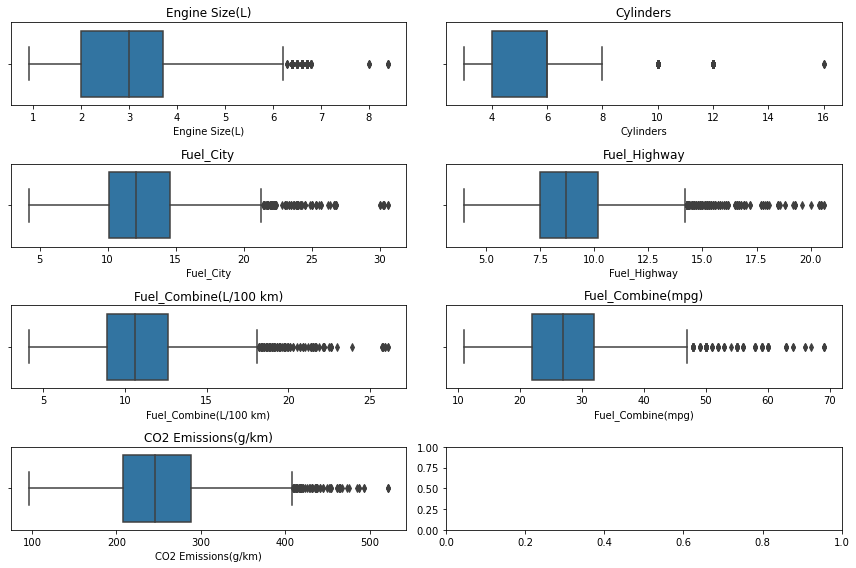

In [14]:
fig,axes=plt.subplots(4, 2, figsize=(12, 8))

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=dataset[feature], ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(feature)

plt.tight_layout()
plt.show()

### IQR Method

In [15]:
for feature in numerical_features:
    
    Q1=dataset[feature].quantile(0.25)
    Q3=dataset[feature].quantile(0.75)
    
    IQR=Q3-Q1
    
    lower=Q1 - 1.5*IQR
    upper=Q3 + 1.5*IQR
    
    outliers=dataset[(dataset[feature] < lower) | (dataset[feature] > upper)]
    
    print(f'{feature}:\n')
    print(f"Total Ouliers: {len(outliers)}")
    print(f"Percentage in Dataset: {(len(outliers)/len(dataset)*100):.2f} %\n\n")     
    print(f'{"*"*30}\n')


Engine Size(L):

Total Ouliers: 137
Percentage in Dataset: 1.86 %


******************************

Cylinders:

Total Ouliers: 196
Percentage in Dataset: 2.65 %


******************************

Fuel_City:

Total Ouliers: 132
Percentage in Dataset: 1.79 %


******************************

Fuel_Highway:

Total Ouliers: 208
Percentage in Dataset: 2.82 %


******************************

Fuel_Combine(L/100 km):

Total Ouliers: 142
Percentage in Dataset: 1.92 %


******************************

Fuel_Combine(mpg):

Total Ouliers: 114
Percentage in Dataset: 1.54 %


******************************

CO2 Emissions(g/km):

Total Ouliers: 80
Percentage in Dataset: 1.08 %


******************************



<b>Boxplot</b> and <b>IQR</b> analysis identified between <b>1.08%</b> and <b>2.82%</b> outliers across the numerical features.

These observations correspond to vehicles with unusually large engines, higher cylinder counts, or high fuel consumption.

Since these values represent <b>valid vehicle specifications</b> rather than <b>data entry errors</b>, they were retained to preserve the real-world variability of the dataset and improve the model's ability to generalize to different types of vehicles.

## Exploratory Data Analysis

### Summary Statistics for Numerical Variables

In [16]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel_City,7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel_Highway,7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel_Combine(L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel_Combine(mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


### Summary Statistics for Categorical Variables

In [17]:
dataset.describe(include='object').T

,count,unique,top,freq
Make,7385,42,Ford,628
Model,7385,1591,Mustang,35
Vehicle Class,7385,16,Suv - Small,1217
Transmission,7385,27,As6,1324
Fuel Type,7385,5,X,3637


### Skewness

In [18]:
dataset.skew(numeric_only=True)

Engine Size(L)            0.809181
Cylinders                 1.110415
Fuel_City                 0.809005
Fuel_Highway              1.079217
Fuel_Combine(L/100 km)    0.893316
Fuel_Combine(mpg)         0.977034
CO2 Emissions(g/km)       0.526094
dtype: float64

### Kurtosis

In [19]:
dataset.kurt(numeric_only=True)

Engine Size(L)           -0.131963
Cylinders                 1.525175
Fuel_City                 1.196145
Fuel_Highway              2.008969
Fuel_Combine(L/100 km)    1.393575
Fuel_Combine(mpg)         2.499369
CO2 Emissions(g/km)       0.478801
dtype: float64

### No. of Unique Values

In [20]:
dataset.nunique()

Make                        42
Model                     1591
Vehicle Class               16
Engine Size(L)              51
Cylinders                    8
Transmission                27
Fuel Type                    5
Fuel_City                  211
Fuel_Highway               143
Fuel_Combine(L/100 km)     181
Fuel_Combine(mpg)           54
CO2 Emissions(g/km)        331
dtype: int64

### Top 10 in Categorical Feature

In [21]:
print('Top 10 in Categorical Feature:\n')

for feature in categorical_features:
    print(f'{feature}:\n')
    print(dataset[feature].value_counts().head(10))
    print()
print(f'{"Cylinders"}:\n')
print(dataset['Cylinders'].value_counts().head(10))
print()

Top 10 in Categorical Feature:

Make:

Ford             628
Chevrolet        588
Bmw              527
Mercedes-Benz    419
Porsche          376
Toyota           330
Gmc              328
Audi             286
Nissan           259
Jeep             251
Name: Make, dtype: int64

Model:

Mustang          35
F-150 Ffv        32
F-150 Ffv 4X4    32
Sierra 4Wd       30
Silverado 4Wd    30
Accord           27
Silverado        27
Sierra           27
Camaro           26
Tacoma 4Wd       25
Name: Model, dtype: int64

Vehicle Class:

Suv - Small                1217
Mid-Size                   1133
Compact                    1022
Suv - Standard              735
Full-Size                   639
Subcompact                  606
Pickup Truck - Standard     538
Two-Seater                  460
Minicompact                 326
Station Wagon - Small       252
Name: Vehicle Class, dtype: int64

Transmission:

As6    1324
As8    1211
M6      901
A6      789
A8      490
Am7     445
A9      339
As7     319
Av      

### Univariate Analysis(Numerical)

Engine Size(L):



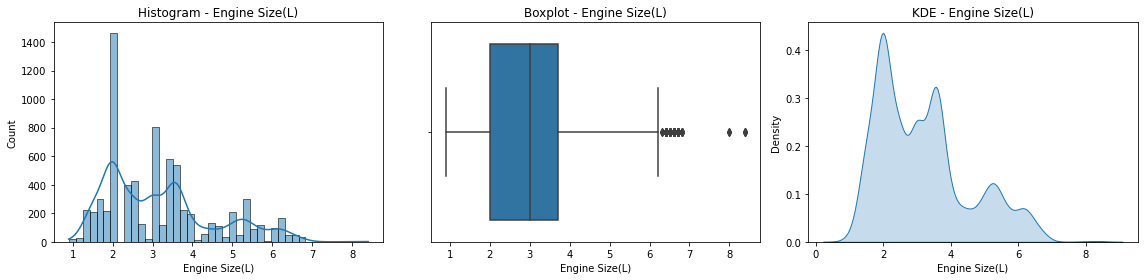

Cylinders:



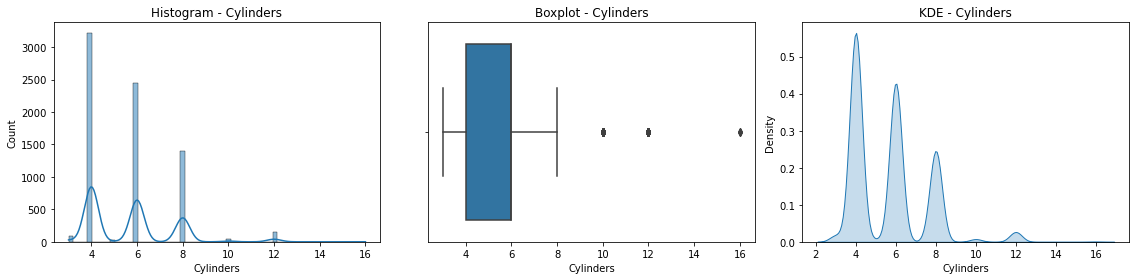

Fuel_City:



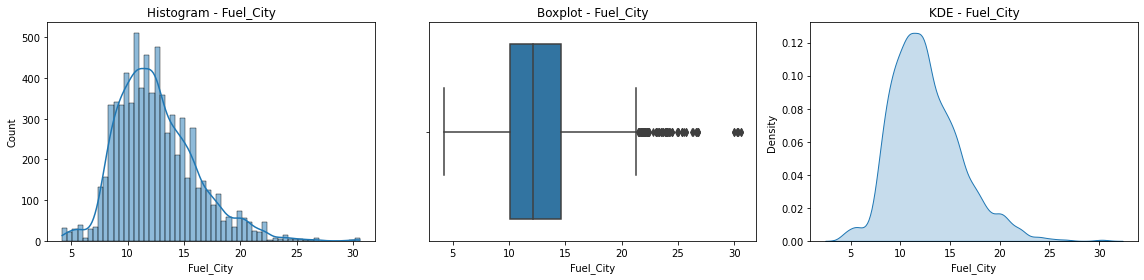

Fuel_Highway:



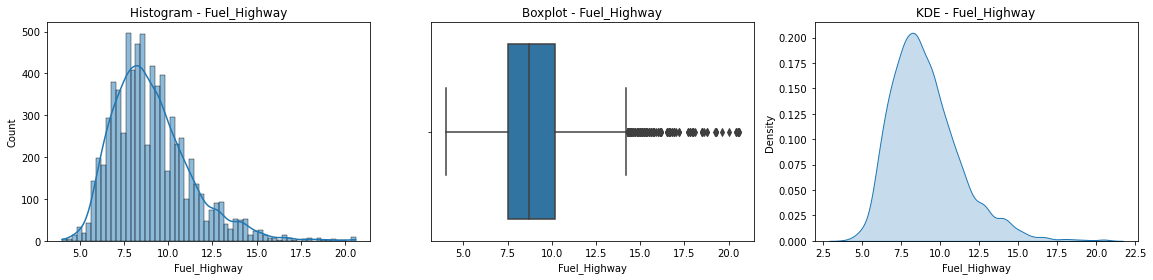

Fuel_Combine(L/100 km):



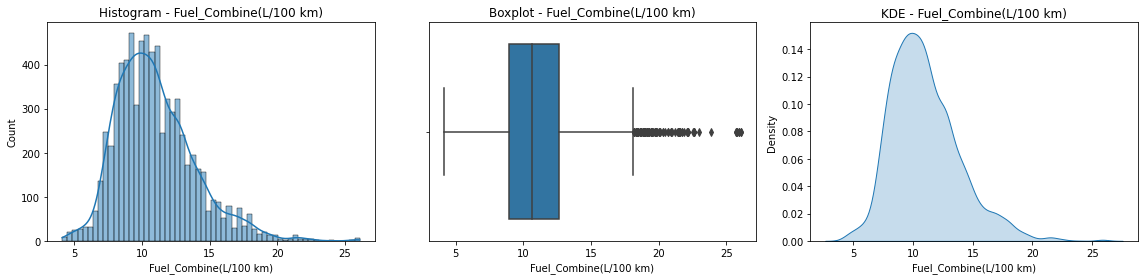

Fuel_Combine(mpg):



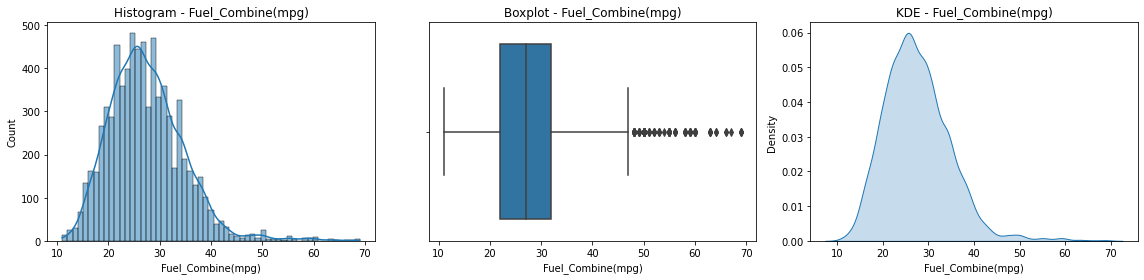

CO2 Emissions(g/km):



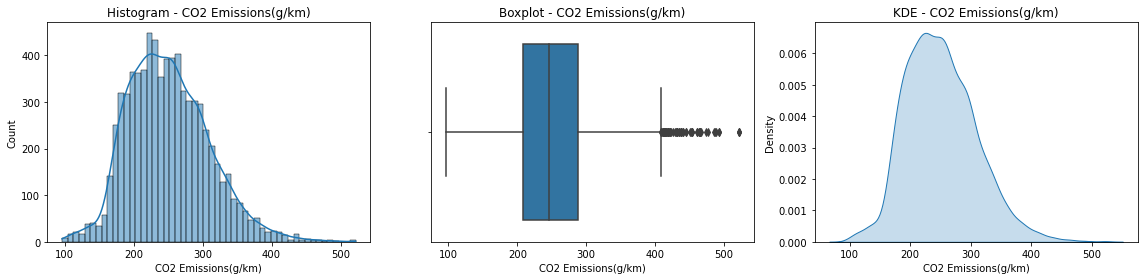

In [22]:
for col in numerical_features:
    fig, ax = plt.subplots(1, 3, figsize=(16,4))
    print(f'{col}:\n')
    sns.histplot(dataset[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram - {col}')

    sns.boxplot(x=dataset[col], ax=ax[1])
    ax[1].set_title(f'Boxplot - {col}')

    sns.kdeplot(dataset[col], fill=True, ax=ax[2])
    ax[2].set_title(f'KDE - {col}')

    plt.tight_layout()
    plt.show()

### Univariate Analysis(Categorical)

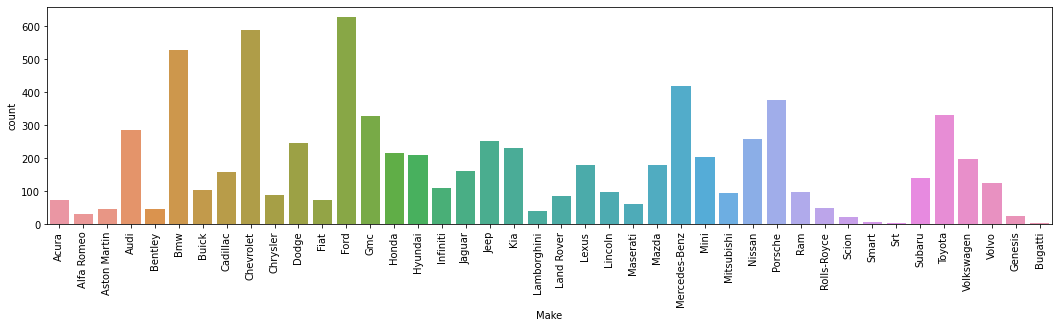

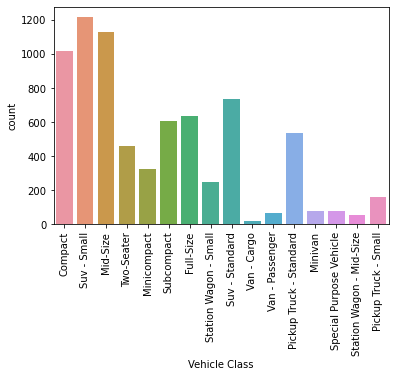

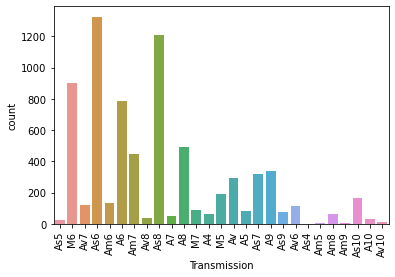

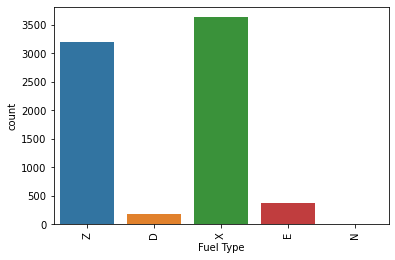

In [23]:
plt.figure(figsize=(18,4))

categorical_features=['Make','Vehicle Class', 'Transmission', 'Fuel Type']

for col in categorical_features:
    sns.countplot(x=dataset[col])
    plt.xticks(rotation=90)
    plt.show()

### Multivariate Analysis

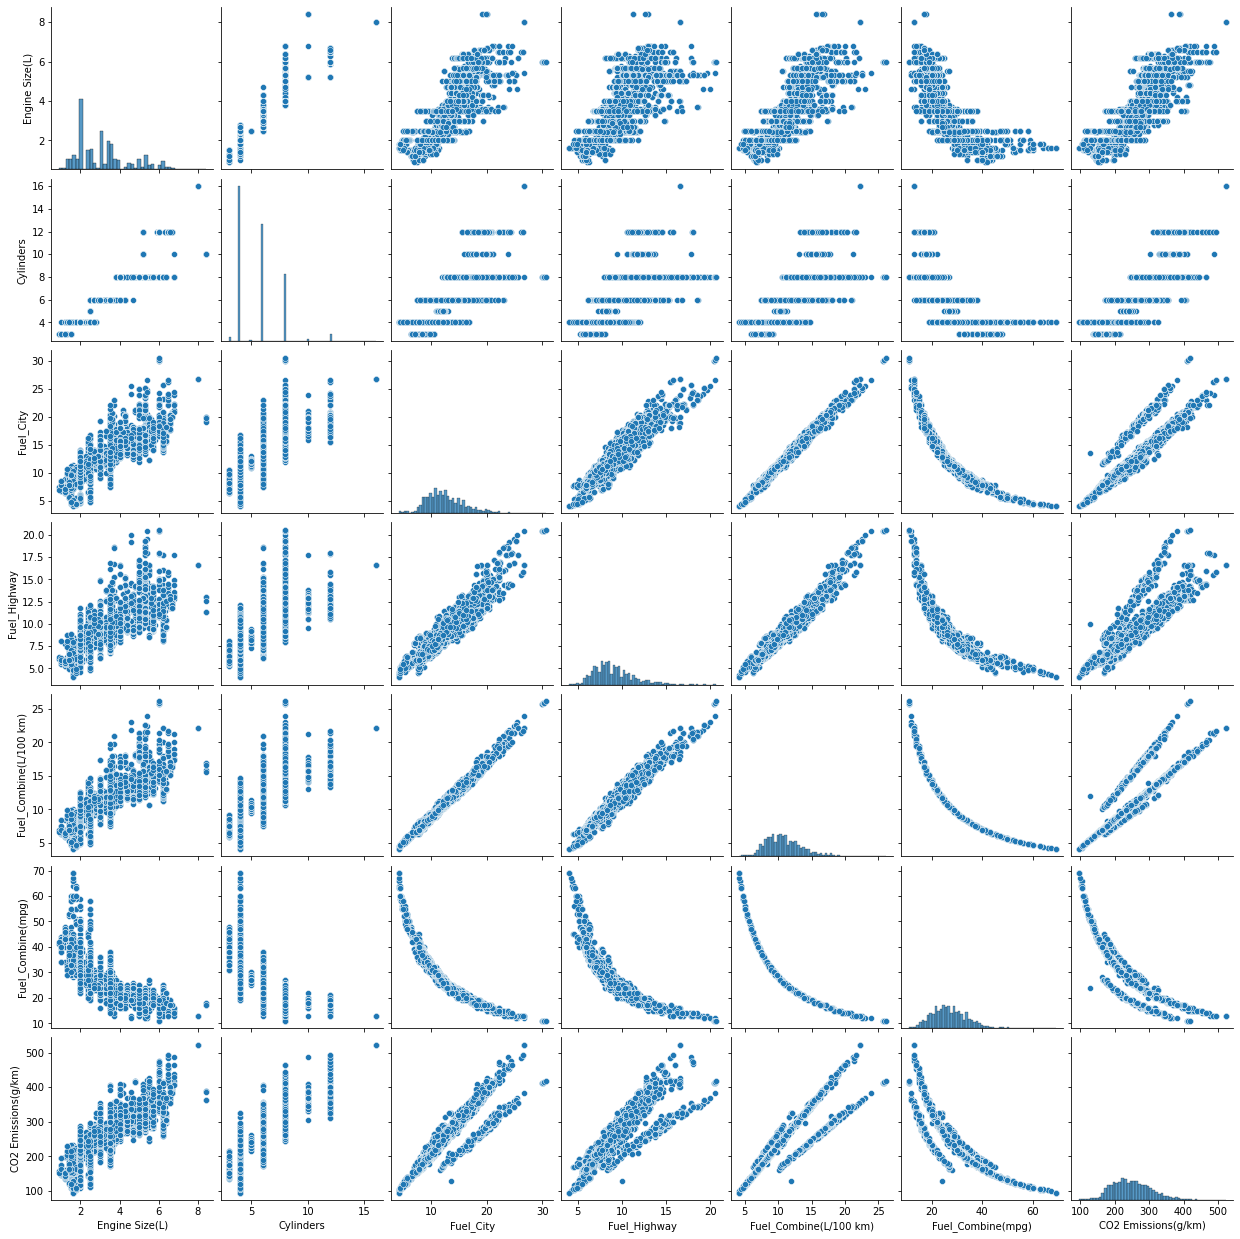

In [24]:
sns.pairplot(data=dataset)

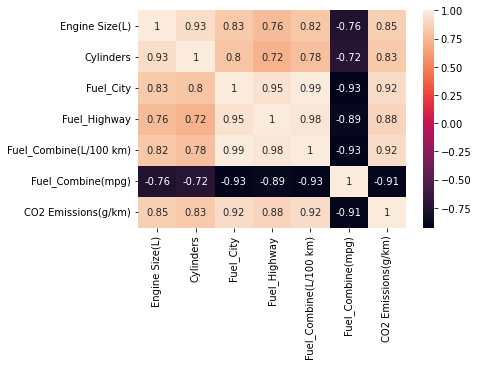

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(dataset.corr(),annot=True);

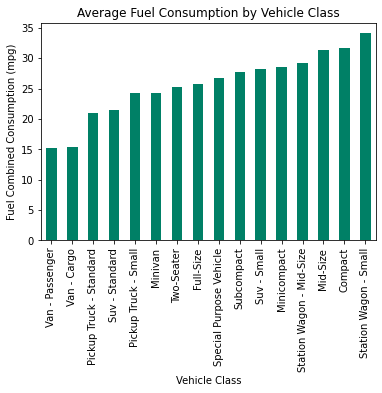

In [26]:
avg_fuel=dataset.groupby('Vehicle Class')['Fuel_Combine(mpg)'].mean().sort_values()
avg_fuel.plot(kind='bar',cmap='summer')

plt.title('Average Fuel Consumption by Vehicle Class')
plt.ylabel('Fuel Combined Consumption (mpg)');

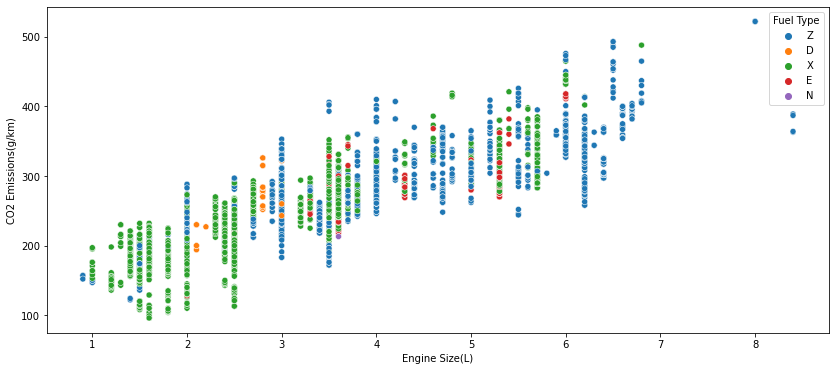

In [27]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='Engine Size(L)',y='CO2 Emissions(g/km)',data=dataset,hue='Fuel Type');

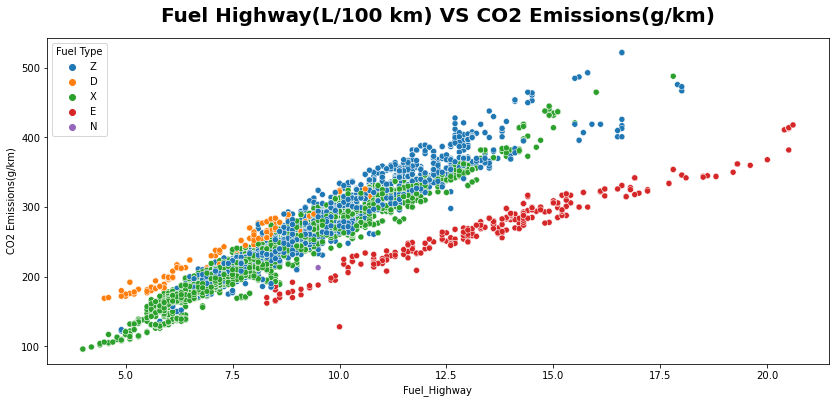

In [28]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='Fuel_Highway',y='CO2 Emissions(g/km)',data=dataset,hue='Fuel Type');
plt.title('Fuel Highway(L/100 km) VS CO2 Emissions(g/km)',y=1.03,fontsize=20,fontweight='bold');

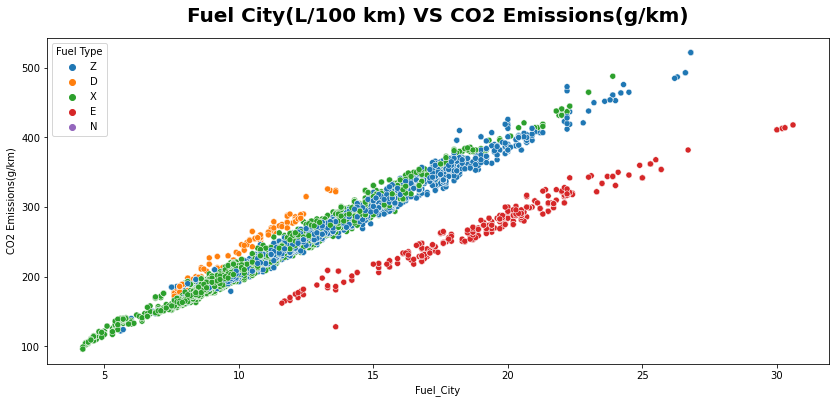

In [29]:
plt.figure(figsize=(14,6))
sns.scatterplot(x='Fuel_City',y='CO2 Emissions(g/km)',data=dataset,hue='Fuel Type');
plt.title('Fuel City(L/100 km) VS CO2 Emissions(g/km)',y=1.03,fontsize=20,fontweight='bold');

## Encoding Categorical Data

### Frequency Encoding on Car Model

Since the Model feature contains more than 1500 unique categories, Frequency Encoding is used instead of One-Hot Encoding to avoid high dimensionality.

In [30]:
model_frequency=dataset['Model'].value_counts().to_dict()
dataset['Model']=dataset['Model'].map(model_frequency)

### OneHotEncoding and StandardScaling (Pipeline)

In [33]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features=['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']
numerical_features= ['Engine Size(L)', 'Cylinders', 'Fuel_City', 'Fuel_Highway', 'Fuel_Combine(L/100 km)', 'Fuel_Combine(mpg)']

oheTransformer=OneHotEncoder(drop='first',handle_unknown='ignore')
scTransformer=StandardScaler()


preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',oheTransformer,categorical_features),
        ('StandardScaler',scTransformer,numerical_features)
    ],remainder='passthrough'
)


## Independent and Dependent Data

In [34]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

X

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel_City,Fuel_Highway,Fuel_Combine(L/100 km),Fuel_Combine(mpg)
0,Acura,9,Compact,2.0,4,As5,Z,9.9,6.7,8.5,33
1,Acura,9,Compact,2.4,4,M6,Z,11.2,7.7,9.6,29
2,Acura,2,Compact,1.5,4,Av7,Z,6.0,5.8,5.9,48
3,Acura,1,Suv - Small,3.5,6,As6,Z,12.7,9.1,11.1,25
4,Acura,7,Suv - Small,3.5,6,As6,Z,12.1,8.7,10.6,27
...,...,...,...,...,...,...,...,...,...,...,...
7380,Volvo,2,Suv - Small,2.0,4,As8,Z,10.7,7.7,9.4,30
7381,Volvo,6,Suv - Small,2.0,4,As8,Z,11.2,8.3,9.9,29
7382,Volvo,6,Suv - Small,2.0,4,As8,Z,11.7,8.6,10.3,27
7383,Volvo,5,Suv - Standard,2.0,4,As8,Z,11.2,8.3,9.9,29


## Train Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [36]:
type(X_train)

pandas.core.frame.DataFrame

## Model Training

### Picking up the Best Model

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

model_params = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False]
        }
    },

    'DecisionTreeRegressor': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    },

    'RandomForestRegressor': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20]
        }
    },

    'AdaBoostRegressor': {
        'model': AdaBoostRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 1]
        }
    },

    'GradientBoostingRegressor': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        }
    }
}


scores = []

for model_name, mp in model_params.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', mp['model'])
    ])

    params = {}

    for key, value in mp['params'].items():
        params['model__' + key] = value

    clf = GridSearchCV(
        pipeline,
        param_grid=params,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    clf.fit(X_train, y_train)

    scores.append({
        'Model': model_name,
        'Best Score': clf.best_score_,
        'Best Parameters': clf.best_params_
    })

scores_df = pd.DataFrame(scores)

In [38]:
scores_df

,Model,Best Score,Best Parameters
0,LinearRegression,-22.328184,{'model__fit_intercept': True}
1,DecisionTreeRegressor,-19.139308,"{'model__max_depth': 10, 'model__min_samples_s..."
2,RandomForestRegressor,-15.175486,"{'model__max_depth': 20, 'model__n_estimators'..."
3,AdaBoostRegressor,-156.939880,"{'model__learning_rate': 0.1, 'model__n_estima..."
4,GradientBoostingRegressor,-11.070891,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [39]:
clf.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Make', 'Vehicle Class',
                                                   'Transmission',
                                                   'Fuel Type']),
                                                 ('StandardScaler',
                                                  StandardScaler(),
                                                  ['Engine Size(L)',
                                                   'Cylinders', 'Fuel_City',
                                                   'Fuel_Highway',
                                                   'Fuel_Combine(L/100 km)',
                                                   'Fuel_Combine(mpg)'])])),
                ('model',
                 GradientBoostingRegressor(max_depth=5, n_estimators=200,
                                           random_state=42))])

In [40]:
clf.best_score_

-11.070890910103795

In [41]:
clf.best_index_

7

The best model from above all models training, is GradientBoostingRegressor which is performing great.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', GradientBoostingRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=200,
        random_state=42
    ))
])

# Train the model
final_pipeline.fit(X_train, y_train)

# Predictions
y_pred_train = final_pipeline.predict(X_train)
y_pred_test = final_pipeline.predict(X_test)

# Training Metrics
model_train_r2_score = r2_score(y_train, y_pred_train)
model_train_MAE = mean_absolute_error(y_train, y_pred_train)
model_train_MSE = mean_squared_error(y_train, y_pred_train)
model_train_RMSE = root_mean_squared_error(y_train, y_pred_train)

# Testing Metrics
model_test_r2_score = r2_score(y_test, y_pred_test)
model_test_MAE = mean_absolute_error(y_test, y_pred_test)
model_test_MSE = mean_squared_error(y_test, y_pred_test)
model_test_RMSE = root_mean_squared_error(y_test, y_pred_test)

training_scores = [
    model_train_r2_score,
    model_train_MAE,
    model_train_MSE,
    model_train_RMSE
]

testing_scores = [
    model_test_r2_score,
    model_test_MAE,
    model_test_MSE,
    model_test_RMSE
]

results=pd.DataFrame({"Training": training_scores,"Testing": testing_scores}, index=["R2_score", "MAE", "MSE", "RMSE"])
print(results)

          Training    Testing
R2_score  0.998768   0.996477
MAE       1.573507   2.114181
MSE       4.240280  11.898015
RMSE      2.059194   3.449350


In [43]:
import joblib

joblib.dump(model_frequency, "model_frequency.pkl")
joblib.dump(final_pipeline, "co2_pipeline.pkl")

['co2_pipeline.pkl']

## Conclusion

- The dataset was explored and preprocessed by checking for missing values, duplicate records, and feature distributions to ensure data quality.
- Exploratory Data Analysis (EDA) revealed strong positive relationships between engine size, fuel consumption, and CO₂ emissions.
- Fuel consumption is the strongest predictor of CO₂ emissions.
- Larger engines generally emit more CO₂.
- Fuel Combined MPG has an inverse relationship with emissions.
- Among all the trained models, the **Gradient Boosting Regressor** achieved the best overall performance, indicating its ability to effectively capture the relationship between vehicle characteristics and CO₂ emissions.
- This project highlights the importance of data preprocessing, exploratory data analysis, and model comparison in building reliable predictive models.